In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import qkeras
import hls4ml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os

# PATH Vitis HLS installation
os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2024.1/bin:' + os.environ['PATH']
os.environ['PATH']

os.environ["XILINX_AP_INCLUDE"] = "-I/tools/Xilinx/Vitis_HLS/2024.1/include"
print(os.environ["XILINX_AP_INCLUDE"])

2026-04-23 23:45:04.615090: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 23:45:04.616567: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 23:45:04.646545: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 23:45:04.647143: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 23:45:05.157116: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

-I/tools/Xilinx/Vitis_HLS/2024.1/include


### Quantization-Aware Training

Epoch 1/32
966/966 [==============================] - 2s 1ms/step - loss: 0.1687 - accuracy: 0.9526 - val_loss: 0.0447 - val_accuracy: 0.9979
Epoch 2/32
966/966 [==============================] - 1s 854us/step - loss: 0.0299 - accuracy: 0.9976 - val_loss: 0.0196 - val_accuracy: 0.9982
Epoch 3/32
966/966 [==============================] - 1s 814us/step - loss: 0.0166 - accuracy: 0.9977 - val_loss: 0.0130 - val_accuracy: 0.9975
Epoch 4/32
966/966 [==============================] - 1s 846us/step - loss: 0.0130 - accuracy: 0.9975 - val_loss: 0.0111 - val_accuracy: 0.9979
Epoch 5/32
966/966 [==============================] - 1s 881us/step - loss: 0.0102 - accuracy: 0.9977 - val_loss: 0.0090 - val_accuracy: 0.9973
Epoch 6/32
966/966 [==============================] - 1s 832us/step - loss: 0.0085 - accuracy: 0.9981 - val_loss: 0.0094 - val_accuracy: 0.9982
Epoch 7/32
966/966 [==============================] - 1s 889us/step - loss: 0.0089 - accuracy: 0.9978 - val_loss: 0.0147 - val_accuracy: 0

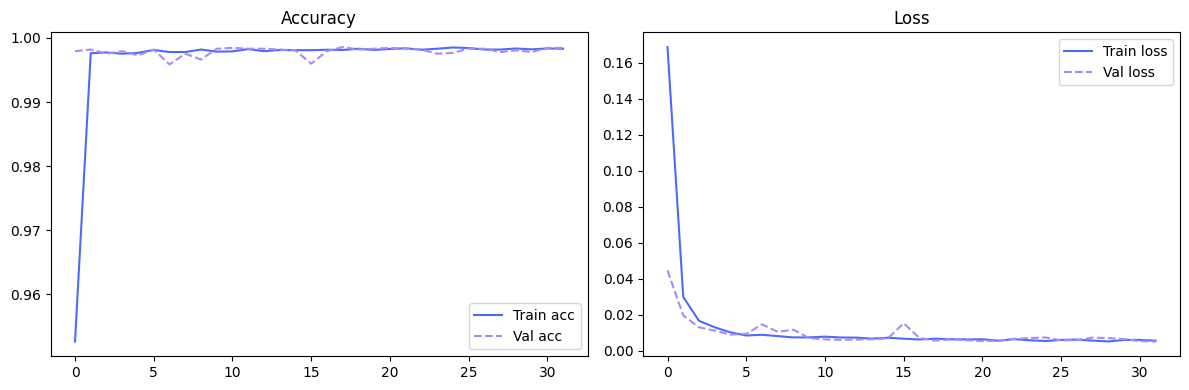

242/242 [==============================] - 1s 561us/step


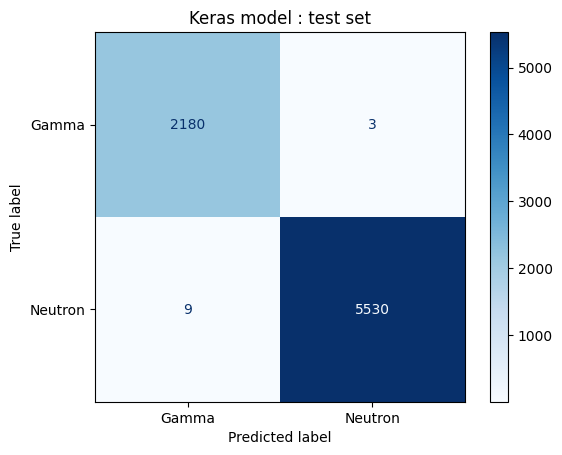

In [3]:

# 1. Load & preprocess data
df = pd.read_csv('../dataset/gamma_neutron.csv')
X_raw = df.drop('class', axis=1).values.astype('float32')
y_raw = df['class'].values
num_classes = len(np.unique(y_raw))

# Per-sample normalization (same as KalEdge Part A)
row_min = X_raw.min(axis=1, keepdims=True)
row_max = X_raw.max(axis=1, keepdims=True)
X = (X_raw - row_min) / (row_max - row_min + 1e-8)
y = tf.keras.utils.to_categorical(y_raw, num_classes)

# Stratified 80/20 train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_raw
)

# 2. Build QKeras model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X.shape[1],)),
    qkeras.QDense(8,
        kernel_quantizer="quantized_bits(8,4)",
        bias_quantizer="quantized_bits(8,4)"),
    qkeras.QActivation("quantized_relu(8)"),
    qkeras.QDense(4,
        kernel_quantizer="quantized_bits(8,4)",
        bias_quantizer="quantized_bits(8,4)"),
    qkeras.QActivation("quantized_relu(8)"),
    qkeras.QDense(num_classes, activation="softmax")
])

# 3. Train (QAT)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train, y_train,
    epochs=32, batch_size=32,
    validation_data=(X_test, y_test)
)

# 4. Evaluate & visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training curves
axes[0].plot(history.history['accuracy'],  color='#4B6CF7', label='Train acc')
axes[0].plot(history.history['val_accuracy'], color='#A78BFA',label='Val acc', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], color='#4B6CF7', label='Train loss')
axes[1].plot(history.history['val_loss'], color='#A78BFA',label='Val loss', linestyle='--')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Confusion matrix on the held-out test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Gamma', 'Neutron']).plot(cmap='Blues')
plt.title('Keras model : test set'); plt.show()





In [4]:
# 5. Convert to hls4ml
import os, shutil

out_dir = 'hls4ml_prj'
if os.path.isdir(out_dir):  # clean previous run
    shutil.rmtree(out_dir)

config = hls4ml.utils.config_from_keras_model(model, granularity='name')
config['Model']['Precision'] = 'ap_fixed<16,6>'
config['Model']['ReuseFactor'] = 8
config['Model']['Strategy'] = 'Latency'

hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir=out_dir,
    part='xczu3eg-ffvb1156-1-e'  # Ultra96-V2
)
# compile() writes firmware, no Vitis HLS needed in PATH
# (use hls_model.build() only if Vitis HLS is installed locally)
hls_model.compile()

# 6. Patch generated files for Vitis HLS 2024.1 compatibility
for root, _, files in os.walk(out_dir):
    for fname in files:
        p = os.path.join(root, fname)
        if fname.endswith('.tcl'):
            txt = open(p).read()
            lines = [('# ' + l if 'config_array_partition -maximum_size' in l
                     else l.replace('-std=c++0x', '-std=c++11'))
                     for l in txt.splitlines()]
            open(p, 'w').write('\n'.join(lines))
        if fname.endswith(('.cpp', '.h')):
            txt = open(p).read()
            txt = txt.replace('#pragma HLS INLINE region', '#pragma HLS INLINE')
            if '#include <iostream>' in txt and '#ifndef __SYNTHESIS__' not in txt:
                txt = txt.replace('#include <iostream>',
                    '#ifndef __SYNTHESIS__\n#include <iostream>\n#endif')
            open(p, 'w').write(txt)
print('hls4ml project ready in:', out_dir)

Interpreting Sequential
Topology:
Layer name: flatten_input, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: q_dense, layer type: QDense, input shapes: [[None, 161]], output shape: [None, 8]
Layer name: q_activation, layer type: Activation, input shapes: [[None, 8]], output shape: [None, 8]
Layer name: q_dense_1, layer type: QDense, input shapes: [[None, 8]], output shape: [None, 4]
Layer name: q_activation_1, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: q_dense_2, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 2]
Interpreting Sequential
Topology:
Layer name: flatten_input, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: q_dense, layer type: QDense,

### Knowledge Distillation + QAP

In [5]:
import numpy as np
import tensorflow as tf
import qkeras
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Teacher: larger float MLP
teacher = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1]) # logits (no softmax)
], name='teacher')

teacher.compile(optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
teacher.fit(X_train, y_train, epochs=40, batch_size=32,
    validation_data=(X_test, y_test), verbose=1)
print(f"Teacher val acc: {teacher.evaluate(X_test, y_test, verbose=0)[1]:.4f}")

Epoch 1/40
966/966 [==============================] - 1s 821us/step - loss: 0.0461 - accuracy: 0.9823 - val_loss: 0.0076 - val_accuracy: 0.9979
Epoch 2/40
966/966 [==============================] - 1s 723us/step - loss: 0.0091 - accuracy: 0.9971 - val_loss: 0.0091 - val_accuracy: 0.9975
Epoch 3/40
966/966 [==============================] - 1s 679us/step - loss: 0.0085 - accuracy: 0.9973 - val_loss: 0.0211 - val_accuracy: 0.9931
Epoch 4/40
966/966 [==============================] - 1s 650us/step - loss: 0.0089 - accuracy: 0.9974 - val_loss: 0.0071 - val_accuracy: 0.9981
Epoch 5/40
966/966 [==============================] - 1s 672us/step - loss: 0.0078 - accuracy: 0.9979 - val_loss: 0.0075 - val_accuracy: 0.9979
Epoch 6/40
966/966 [==============================] - 1s 672us/step - loss: 0.0072 - accuracy: 0.9979 - val_loss: 0.0072 - val_accuracy: 0.9982
Epoch 7/40
966/966 [==============================] - 1s 627us/step - loss: 0.0074 - accuracy: 0.9977 - val_loss: 0.0128 - val_accuracy:

In [6]:
def build_student():
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
        qkeras.QDense(4,
            kernel_quantizer="quantized_bits(8,4)",
            bias_quantizer="quantized_bits(8,4)"),
        qkeras.QActivation("quantized_relu(8)"),
        qkeras.QDense(16,
            kernel_quantizer="quantized_bits(8,4)",
            bias_quantizer="quantized_bits(8,4)"),
        qkeras.QActivation("quantized_relu(8)"),
        qkeras.QDense(y_train.shape[1]) # logits: no softmax
    ], name='student')

In [7]:
TEMPERATURE = 4.0 # soften teacher distribution
ALPHA = 0.3 # weight of hard label loss
SPARSITY = 0.30 # target pruning sparsity
EPOCHS = 40
BATCH_SIZE = 32
PRUNE_START = 5 # epoch to begin pruning (let KD warm up first)
PRUNE_END = 35 # epoch to reach full sparsity (leave tail clean)

# Distiller (mirrors KalEdge ml_core_kd.py)
hard_loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
kl = tf.keras.losses.KLDivergence()

class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self._acc = tf.keras.metrics.CategoricalAccuracy(name='accuracy')

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer

    def train_step(self, data):
        x, y = data
        t_logits = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            s_logits = self.student(x, training=True)
            hard = hard_loss(y, s_logits)
            t_soft = tf.nn.softmax(t_logits / TEMPERATURE)
            s_soft = tf.nn.softmax(s_logits / TEMPERATURE)
            soft = kl(t_soft, s_soft) * (TEMPERATURE ** 2)
            loss = ALPHA * hard + (1 - ALPHA) * soft
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self._acc.update_state(y, tf.nn.softmax(s_logits))
        return {'loss': loss, 'accuracy': self._acc.result()}

    def test_step(self, data):
        x, y = data
        s_logits = self.student(x, training=False)
        self._acc.update_state(y, tf.nn.softmax(s_logits))
        return {'loss': hard_loss(y, s_logits), 'accuracy': self._acc.result()}

# Apply pruning schedule to the QKeras student
steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=SPARSITY,
    begin_step=PRUNE_START * steps_per_epoch,
    end_step=PRUNE_END * steps_per_epoch)

student_pruned = tfmot.sparsity.keras.prune_low_magnitude(
    build_student(), pruning_schedule=schedule)

distiller = Distiller(student_pruned, teacher)
distiller.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

hist_kd = distiller.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Strip pruning masks to get the clean deployable model
student_final = tfmot.sparsity.keras.strip_pruning(distiller.student)

Epoch 1/40
966/966 [==============================] - 4s 2ms/step - loss: 3.5278 - accuracy: 0.7366 - val_loss: 0.3441 - val_accuracy: 0.9766
Epoch 2/40
966/966 [==============================] - 1s 1ms/step - loss: 1.2997 - accuracy: 0.9870 - val_loss: 0.0684 - val_accuracy: 0.9973
Epoch 3/40
966/966 [==============================] - 1s 1ms/step - loss: 0.7353 - accuracy: 0.9974 - val_loss: 0.0163 - val_accuracy: 0.9974
Epoch 4/40
966/966 [==============================] - 1s 1ms/step - loss: 0.4514 - accuracy: 0.9979 - val_loss: 0.0043 - val_accuracy: 0.9979
Epoch 5/40
966/966 [==============================] - 1s 1ms/step - loss: 0.2876 - accuracy: 0.9976 - val_loss: 0.0013 - val_accuracy: 0.9978
Epoch 6/40
966/966 [==============================] - 1s 1ms/step - loss: 0.1887 - accuracy: 0.9979 - val_loss: 4.3659e-04 - val_accuracy: 0.9979
Epoch 7/40
966/966 [==============================] - 1s 1ms/step - loss: 0.1309 - accuracy: 0.9978 - val_loss: 1.6597e-04 - val_accuracy: 0.998

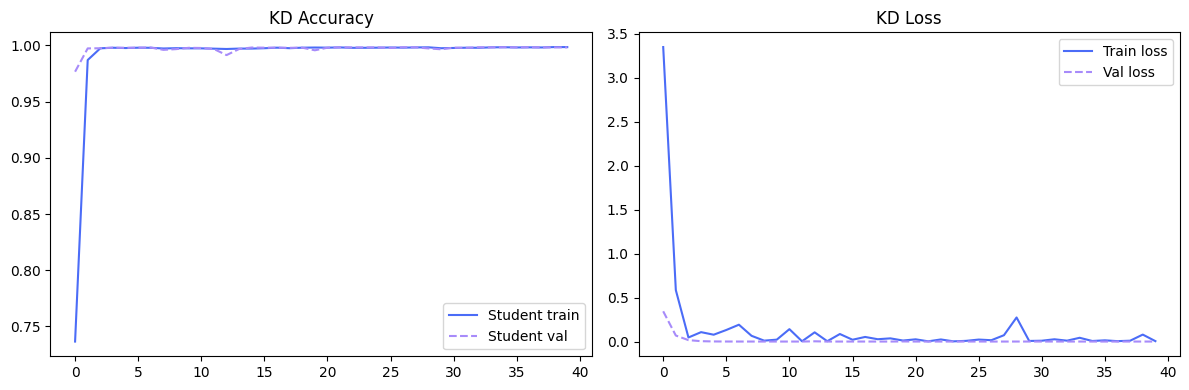

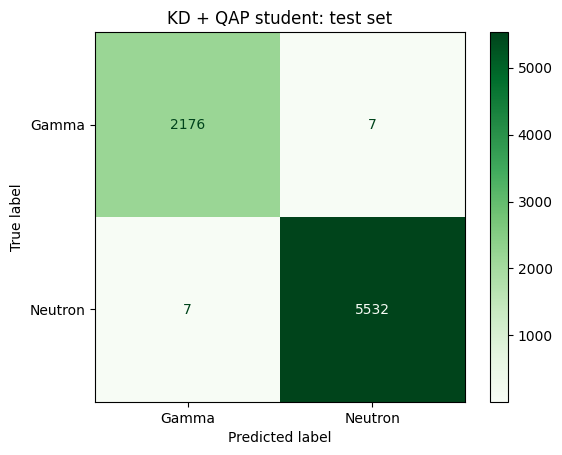

In [8]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_kd.history['accuracy'], color='#4B6CF7', label='Student train')
axes[0].plot(hist_kd.history['val_accuracy'], color='#A78BFA', label='Student val', linestyle='--')
axes[0].set_title('KD Accuracy'); axes[0].legend()
axes[1].plot(hist_kd.history['loss'], color='#4B6CF7', label='Train loss')
axes[1].plot(hist_kd.history['val_loss'], color='#A78BFA', label='Val loss', linestyle='--')
axes[1].set_title('KD Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Confusion matrix: student_final
y_pred = np.argmax(tf.nn.softmax(student_final(X_test)).numpy(), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Gamma', 'Neutron']).plot(cmap='Greens')
plt.title('KD + QAP student: test set'); plt.show()


In [9]:

# Convert the pruned student to hls4ml
import os, shutil

out_dir_kd = 'hls4ml_prj_kd'
if os.path.isdir(out_dir_kd):
    shutil.rmtree(out_dir_kd)

config_kd = hls4ml.utils.config_from_keras_model(student_final, granularity='name')
config_kd['Model']['Precision'] = 'ap_fixed<16,6>'
config_kd['Model']['ReuseFactor'] = 8
config_kd['Model']['Strategy'] = 'Latency'

hls_student = hls4ml.converters.convert_from_keras_model(
    student_final,
    hls_config=config_kd,
    output_dir=out_dir_kd,
    part='xczu3eg-ffvb1156-1-e'
)
hls_student.compile()

# Apply the same Vitis HLS 2024.1 compatibility patches (see Step 11)
for root, _, files in os.walk(out_dir_kd):
    for fname in files:
        p = os.path.join(root, fname)
        if fname.endswith('.tcl'):
            txt = open(p).read()
            lines = [('# ' + l if 'config_array_partition -maximum_size' in l
                     else l.replace('-std=c++0x', '-std=c++11'))
                     for l in txt.splitlines()]
            open(p, 'w').write('\n'.join(lines))
        if fname.endswith(('.cpp', '.h')):
            txt = open(p).read()
            txt = txt.replace('#pragma HLS INLINE region', '#pragma HLS INLINE')
            if '#include <iostream>' in txt and '#ifndef __SYNTHESIS__' not in txt:
                txt = txt.replace('#include <iostream>',
                    '#ifndef __SYNTHESIS__\n#include <iostream>\n#endif')
            open(p, 'w').write(txt)
print('KD+QAP hls4ml project ready in:', out_dir_kd)


Interpreting Sequential
Topology:
Layer name: flatten_2_input, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: flatten_2, layer type: Reshape, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: q_dense_3, layer type: QDense, input shapes: [[None, 161]], output shape: [None, 4]
Layer name: q_activation_2, layer type: Activation, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: q_dense_4, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 16]
Layer name: q_activation_3, layer type: Activation, input shapes: [[None, 16]], output shape: [None, 16]
Layer name: q_dense_5, layer type: QDense, input shapes: [[None, 16]], output shape: [None, 2]
Interpreting Sequential
Topology:
Layer name: flatten_2_input, layer type: InputLayer, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: flatten_2, layer type: Reshape, input shapes: [[None, 161]], output shape: [None, 161]
Layer name: q_dense_3, l

Done
KD+QAP hls4ml project ready in: hls4ml_prj_kd


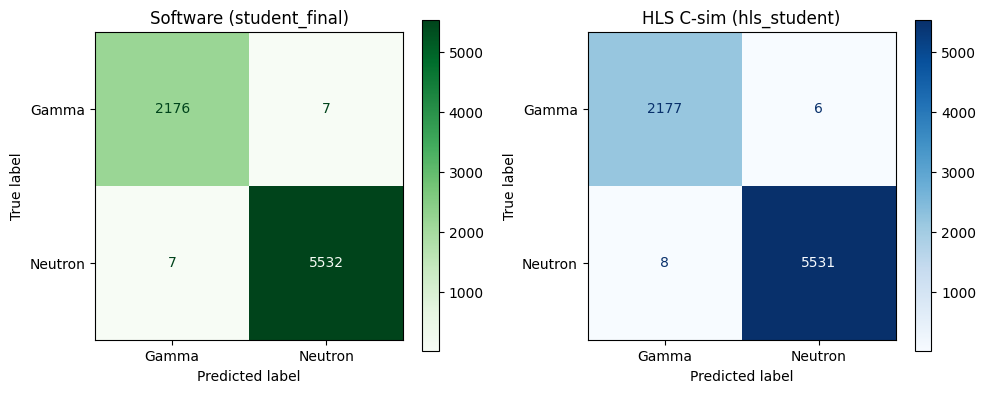

In [10]:

# HLS C-simulation: confusion matrix from the compiled HLS model
y_hls = hls_student.predict(np.ascontiguousarray(X_test))
y_pred_hls = np.argmax(y_hls, axis=1)
cm_hls = confusion_matrix(y_true, y_pred_hls)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=['Gamma','Neutron']).plot(cmap='Greens', ax=axes[0])
ConfusionMatrixDisplay(cm_hls, display_labels=['Gamma','Neutron']).plot(cmap='Blues', ax=axes[1])
axes[0].set_title('Software (student_final)')
axes[1].set_title('HLS C-sim (hls_student)')
plt.tight_layout(); plt.show()

In [11]:
student_final.summary()

Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 161)               0         
                                                                 
 q_dense_3 (QDense)          (None, 4)                 648       
                                                                 
 q_activation_2 (QActivation  (None, 4)                0         
 )                                                               
                                                                 
 q_dense_4 (QDense)          (None, 16)                80        
                                                                 
 q_activation_3 (QActivation  (None, 16)               0         
 )                                                               
                                                                 
 q_dense_5 (QDense)          (None, 2)                 34  